In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

In [9]:

# FIX 1: use raw string
server = r'ARYAS\SQLEXPRESS'
database = 'Loan_DB'

# FIX 2: add TrustServerCertificate
connection_string = f"mssql+pyodbc://{server}/{database}?driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes&TrustServerCertificate=yes"

engine = create_engine(connection_string)

conn = engine.connect()
print("✅ Connected successfully!")

✅ Connected successfully!


In [11]:
df_external= pd.read_sql('SELECT * FROM External_Cibil', engine)
df_internal= pd.read_sql('SELECT * FROM Internal_Bank', engine)

df_internal.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
0,1,5.0,4.0,1.0,0.0,0.0,0.000,0.0,0.200,0.800,...,0.0,0.0,1.0,0.0,4.0,1.0,4.0,0.0,72.0,18.0
1,2,1.0,0.0,1.0,0.0,0.0,0.000,0.0,1.000,0.000,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0,7.0
2,3,8.0,0.0,8.0,1.0,0.0,0.125,0.0,1.000,0.000,...,0.0,6.0,1.0,0.0,0.0,2.0,6.0,0.0,47.0,2.0
3,4,1.0,0.0,1.0,1.0,0.0,1.000,0.0,1.000,0.000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,5.0
4,5,3.0,2.0,1.0,0.0,0.0,0.000,0.0,0.333,0.667,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,2.0,131.0,32.0


In [13]:
df_external.head()

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag,Risk_category,Default_flag
0,1,549.0,35.0,15.0,11.0,29.0,29.0,0.0,0.0,0.0,...,0.0,13.333,1,0,PL,PL,696,P2,Medium Risk,0
1,2,47.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,...,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2,Medium Risk,0
2,3,302.0,11.0,3.0,9.0,25.0,25.0,1.0,9.0,8.0,...,0.0,5741.667,1,0,ConsumerLoan,others,693,P2,Medium Risk,0
3,4,NaN,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,...,0.0,9.900,0,0,others,others,673,P2,Medium Risk,0
4,5,583.0,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,...,0.0,NaN,0,0,AL,AL,753,P1,Low Risk,0


#### Merge datasets

In [16]:
df= pd.merge(df_internal, df_external, on= 'PROSPECTID', how='inner')
df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag,Risk_category,Default_flag
0,1,5.0,4.0,1.0,0.0,0.0,0.000,0.0,0.200,0.800,...,0.0,13.333,1,0,PL,PL,696,P2,Medium Risk,0
1,2,1.0,0.0,1.0,0.0,0.0,0.000,0.0,1.000,0.000,...,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2,Medium Risk,0
2,3,8.0,0.0,8.0,1.0,0.0,0.125,0.0,1.000,0.000,...,0.0,5741.667,1,0,ConsumerLoan,others,693,P2,Medium Risk,0
3,4,1.0,0.0,1.0,1.0,0.0,1.000,0.0,1.000,0.000,...,0.0,9.900,0,0,others,others,673,P2,Medium Risk,0
4,5,3.0,2.0,1.0,0.0,0.0,0.000,0.0,0.333,0.667,...,0.0,NaN,0,0,AL,AL,753,P1,Low Risk,0


### <center><h3>Exploratory Data Analysis</h3></center>

In [18]:
df.shape, df.columns

((51336, 89),
 Index(['PROSPECTID', 'Total_TL', 'Tot_Closed_TL', 'Tot_Active_TL',
        'Total_TL_opened_L6M', 'Tot_TL_closed_L6M', 'pct_tl_open_L6M',
        'pct_tl_closed_L6M', 'pct_active_tl', 'pct_closed_tl',
        'Total_TL_opened_L12M', 'Tot_TL_closed_L12M', 'pct_tl_open_L12M',
        'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL', 'CC_TL',
        'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL',
        'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL',
        'time_since_recent_payment', 'time_since_first_deliquency',
        'time_since_recent_deliquency', 'num_times_delinquent',
        'max_delinquency_level', 'max_recent_level_of_deliq', 'num_deliq_6mts',
        'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts',
        'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std',
        'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts',
        'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 89 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    51336 non-null  int64  
 1   Total_TL                      51336 non-null  float64
 2   Tot_Closed_TL                 51336 non-null  float64
 3   Tot_Active_TL                 51336 non-null  float64
 4   Total_TL_opened_L6M           51336 non-null  float64
 5   Tot_TL_closed_L6M             51336 non-null  float64
 6   pct_tl_open_L6M               51336 non-null  float64
 7   pct_tl_closed_L6M             51336 non-null  float64
 8   pct_active_tl                 51336 non-null  float64
 9   pct_closed_tl                 51336 non-null  float64
 10  Total_TL_opened_L12M          51336 non-null  float64
 11  Tot_TL_closed_L12M            51336 non-null  float64
 12  pct_tl_open_L12M              51336 non-null  float64
 13  p

In [53]:
null_counts= df.isnull().sum()
null_counts= null_counts[null_counts>0]
null_counts

Series([], dtype: int64)

In [28]:
df= df.drop(columns=['Approved_Flag', 'Risk_category'])

In [32]:
df= df.drop(columns=['PROSPECTID'])

In [34]:
df= df.drop(columns=['CC_utilization','PL_utilization','time_since_first_deliquency','max_delinquency_level'])

In [40]:
df= df.drop(columns=['time_since_recent_deliquency','max_unsec_exposure_inPct'])

### Dropped the columns having more than 40%-50% null values 

### Impute the Columns having less than 30% null Values

In [51]:
# Handle/Impute missing values
cols_to_fill= ['time_since_recent_payment','max_deliq_6mts','max_deliq_12mts','time_since_recent_enq','pct_currentBal_all_TL']

for col in cols_to_fill:
    df[col]= df[col].fillna(df[col].median())

In [57]:
df.isnull().sum().sum()

0

### <center><h3>Descriptive Analysis</h3></center>

### Basic Overview

In [70]:
# Shape
print('Shape:', df.shape)

Shape: (51336, 80)


In [72]:
# Summary Stats
df.describe()

,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,...,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,Credit_Score,Default_flag
count,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,...,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000,51336.000000
mean,4.858598,2.770415,2.088184,0.736754,0.428919,0.184574,0.089095,0.577542,0.422458,1.503701,...,0.089469,0.167874,0.190414,0.065182,0.170492,0.056302,0.271116,0.052887,679.859222,0.074139
std,7.177116,5.941680,2.290774,1.296717,0.989972,0.297414,0.205635,0.379867,0.379867,2.119399,...,0.285423,0.373758,0.376218,0.235706,0.350209,0.213506,0.444540,0.223810,20.502764,0.262000
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,469.000000,0.000000
25%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,669.000000,0.000000
50%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.556000,0.444000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,680.000000,0.000000
75%,5.000000,3.000000,3.000000,1.000000,1.000000,0.308000,0.053000,1.000000,0.750000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,691.000000,0.000000
max,235.000000,216.000000,47.000000,27.000000,19.000000,1.000000,1.000000,1.000000,1.000000,39.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,811.000000,1.000000


In [74]:
# Target Distribution
df['Default_flag'].value_counts()

Default_flag
0    47530
1     3806
Name: count, dtype: int64

In [76]:
df['Default_flag'].value_counts(normalize=True)

Default_flag
0    0.925861
1    0.074139
Name: proportion, dtype: float64

In [80]:
# Key feature summary
df[['Credit_Score','NETMONTHLYINCOME','AGE']].describe()

,Credit_Score,NETMONTHLYINCOME,AGE
count,51336.000000,5.133600e+04,51336.000000
mean,679.859222,2.642419e+04,33.758532
std,20.502764,2.002711e+04,8.816364
min,469.000000,0.000000e+00,21.000000
25%,669.000000,1.800000e+04,27.000000
50%,680.000000,2.300000e+04,32.000000
75%,691.000000,3.000000e+04,39.000000
max,811.000000,2.500000e+06,77.000000


In [86]:
(df['NETMONTHLYINCOME']==0).sum()

46

In [88]:
df['NETMONTHLYINCOME']=df['NETMONTHLYINCOME'].replace(0, np.nan)

In [98]:
df['NETMONTHLYINCOME'].isnull().sum()

0

In [96]:
df['NETMONTHLYINCOME']=df['NETMONTHLYINCOME'].fillna(df['NETMONTHLYINCOME'].median())

### Fixed Zero Income: Zero values in income were treated as missing and imputed using median to avoid distortion in model performance.

### Handle extreme outliers (clip)

In [106]:
upper_limit=df['NETMONTHLYINCOME'].quantile(0.99)

In [108]:
df['NETMONTHLYINCOME']=df['NETMONTHLYINCOME'].clip(upper=upper_limit)

In [110]:
df['NETMONTHLYINCOME'].describe()

count    51336.000000
mean     25972.612202
std      12599.490590
min          1.000000
25%      18000.000000
50%      23040.000000
75%      30000.000000
max      78000.000000
Name: NETMONTHLYINCOME, dtype: float64

##### Remove invalid low values

In [115]:
df.loc[df['NETMONTHLYINCOME'] < 1000, 'NETMONTHLYINCOME'] = np.nan

In [119]:
df['NETMONTHLYINCOME'] = df['NETMONTHLYINCOME'].fillna(df['NETMONTHLYINCOME'].median())

In [121]:
df['NETMONTHLYINCOME'].describe()

count    51336.000000
mean     26035.738955
std      12527.910646
min       1000.000000
25%      18000.000000
50%      23500.000000
75%      30000.000000
max      78000.000000
Name: NETMONTHLYINCOME, dtype: float64

### Visual Analysis

In [126]:
import matplotlib.pyplot as plt

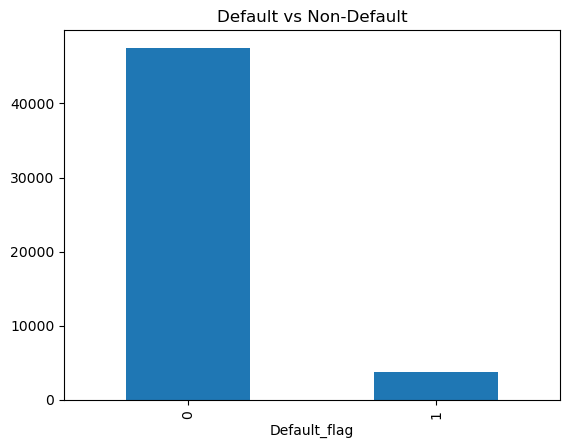

In [128]:
df['Default_flag'].value_counts().plot(kind='bar')
plt.title('Default vs Non-Default')
plt.show()

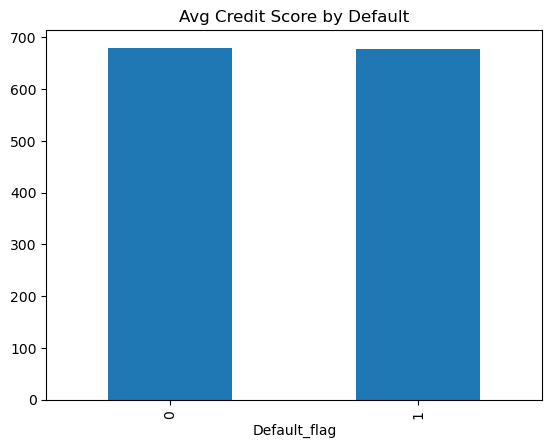

In [134]:
# Credit Score vs Default
df.groupby('Default_flag')['Credit_Score'].mean().plot(kind='bar')
plt.title('Avg Credit Score by Default')
plt.show()

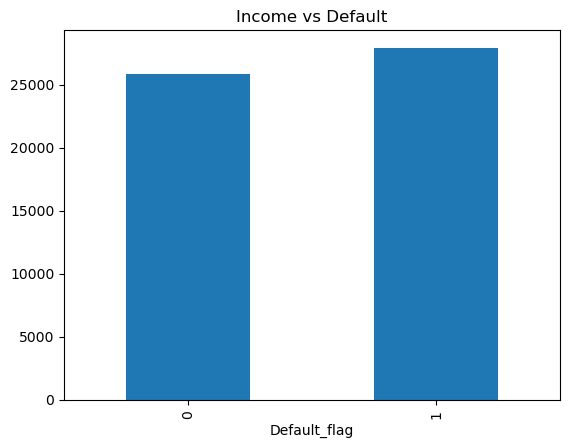

In [136]:
# Income vs Default
df.groupby('Default_flag')['NETMONTHLYINCOME'].mean().plot(kind='bar')
plt.title('Income vs Default')
plt.show()

### <center><h3>Diagnostic Analysis</center></h3>

In [142]:
# Numerical comparison
df.groupby('Default_flag')[['Credit_Score','NETMONTHLYINCOME','AGE']].mean()

,Credit_Score,NETMONTHLYINCOME,AGE
Default_flag,,,
0,680.015064,25883.789943,33.595708
1,677.913032,27933.305045,35.791908


#### Insights-- -Credit score alone is not a strong differentiator in this dataset.
####            -Default customers have higher income-- Higher income does NOT guarantee lower default risk.
####            -Slight increase in default risk with age in this dataset.
#### _None of these features alone strongly explain default._

In [164]:
# Categorical Analysis
pd.crosstab(df['EDUCATION'], df['Default_flag'], normalize='index')

Default_flag,0,1
EDUCATION,,
12TH,0.930670,0.069330
GRADUATE,0.923829,0.076171
OTHERS,0.921838,0.078162
POST-GRADUATE,0.919269,0.080731
PROFESSIONAL,0.925651,0.074349
SSC,0.925830,0.074170
UNDER GRADUATE,0.924253,0.075747


In [160]:
pd.crosstab(df['MARITALSTATUS'], df['Default_flag'], normalize='index')

Default_flag,0,1
MARITALSTATUS,,
Married,0.916799,0.083201
Single,0.951045,0.048955


#### No single feature strongly explains default — hence predictive modeling is required.

### <center><h3>Predictive Model</center><h3>

#### Features & target

In [172]:
x= df.drop(columns=['Default_flag'])
y= df['Default_flag']

#### Encoding

In [177]:
x= pd.get_dummies(x,drop_first=True)
x.head()

,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,...,last_prod_enq2_CC,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,first_prod_enq2_CC,first_prod_enq2_ConsumerLoan,first_prod_enq2_HL,first_prod_enq2_PL,first_prod_enq2_others
0,5.0,4.0,1.0,0.0,0.0,0.000,0.0,0.200,0.800,0.0,...,False,False,False,True,False,False,False,False,True,False
1,1.0,0.0,1.0,0.0,0.0,0.000,0.0,1.000,0.000,1.0,...,False,True,False,False,False,False,True,False,False,False
2,8.0,0.0,8.0,1.0,0.0,0.125,0.0,1.000,0.000,2.0,...,False,True,False,False,False,False,False,False,False,True
3,1.0,0.0,1.0,1.0,0.0,1.000,0.0,1.000,0.000,1.0,...,False,False,False,False,True,False,False,False,False,True
4,3.0,2.0,1.0,0.0,0.0,0.000,0.0,0.333,0.667,0.0,...,False,False,False,False,False,False,False,False,False,False


#### Train-Test Split

In [180]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest= train_test_split(x,y, test_size=0.20, random_state=40)

#### Model Training

In [183]:
from sklearn.linear_model import LogisticRegression
model= LogisticRegression()
model.fit(xtrain,ytrain)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

#### Model Prediction

In [239]:

y_prob=model.predict_proba(xtest)[:,1]
ypred=(y_prob>0.25).astype(int)
y_prob[:1]

array([0.04373086])

#### Model Evaluation

In [201]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

In [241]:
accuracy_score(ytest, ypred)

0.9433190494740943

In [243]:
roc_auc_score(ytest, y_prob)

0.9098458715832421

In [245]:
confusion_matrix(ytest, ypred)

array([[9322,  230],
       [ 352,  364]], dtype=int64)

In [247]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      9552
           1       0.61      0.51      0.56       716

    accuracy                           0.94     10268
   macro avg       0.79      0.74      0.76     10268
weighted avg       0.94      0.94      0.94     10268



#### Threshold tuning was performed to improve recall, reducing false negatives and enhancing detection of high-risk customers.

### <center><h4>Feature Importance (Model Interpretation)</center></h4>

### Get feature importance

In [257]:
feature_importance= pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_[0]})
feature_importance= feature_importance.sort_values(by='Coefficient', ascending=False)
feature_importance.head(10)

,Feature,Coefficient
27,max_recent_level_of_deliq,0.024558
47,recent_level_of_deliq,0.015620
32,max_deliq_12mts,0.011426
23,Age_Oldest_TL,0.011376
26,num_times_delinquent,0.005584
24,Age_Newest_TL,0.005334
35,num_std,0.004960
33,num_times_30p_dpd,0.004602
31,max_deliq_6mts,0.003639
34,num_times_60p_dpd,0.003357


### All top features are related to: DELINQUENCY / PAYMENT HISTORY
#### Customers who have past delays in repayment are most likely to default again.
#### Delinquency-related features like recent delinquency level and past due counts are the most influential predictors, indicating repayment history is the strongest indicator of default risk.

### Save model

In [263]:
import joblib

joblib.dump(model, 'Loan_Default_Model.pkl')
joblib.dump(x.columns, 'Model_columns.pkl')

['Model_columns.pkl']

In [265]:
df['Predicted_prob']=model.predict_proba(x)[:,1]
df.to_csv("scored_data.csv", index=False)